# 05 — Bivariate Feature ↔ Target Analysis

**The signal check.** Everything before this describes the features in isolation. This notebook asks the question that decides whether they are worth modeling at all:

> **Does any feature carry information about the future targets?**

It looks at each feature against all three targets — `future_return`, `future_direction`, `future_realized_vol` — four ways:

1. **Correlation ranking** — linear association, sorted
2. **Leakage guard** — implausibly strong correlations, which are bugs not signal
3. **Decile analysis** — mean target across feature deciles, catching *monotonic non-linear* signal correlation misses
4. **Mutual information** — general (non-linear) dependence



In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="colorblind")

In [2]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.features.schema import (
    FEATURE_NAMES,
    TARGET_NAMES,
    MACRO_FEATURE_NAMES_FULL_HISTORY,
)
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 1,943,662 rows for 497 tickers
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d,short_interest,short_interest_change,days_to_cover,days_to_cover_change
0,2010-01-04,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.772951,22.389128,22.625179,22.267525,22.453505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.558167,22.145924,22.331903,22.002861,22.324751,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.488672,22.067240,22.174536,22.002861,22.067240,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.463404,22.038628,22.045780,21.816881,22.017166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.457090,22.031473,22.067240,21.745352,21.917025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Macro factors join only if merged into the dataset. The full-history subset
# excludes the late-start credit spreads (see schema and notebook 01). They are
# market-wide -- identical across tickers on a date -- so they can track the
# overall volatility regime but not cross-sectional ranking.
macro_present = [c for c in MACRO_FEATURE_NAMES_FULL_HISTORY if c in data.columns and data[c].notna().any()]
base_features = [c for c in FEATURE_NAMES if c in data.columns and data[c].notna().any()]
features = base_features + macro_present
targets = [t for t in TARGET_NAMES if t in data.columns]
print(f"features: {len(features)} ({len(macro_present)} macro)   targets: {targets}")

features: 56 (11 macro)   targets: ['future_return', 'future_direction', 'future_realized_vol']


In [4]:
correlations = {}
for target in targets:
    correlations = {}
    for target in targets:
        correlations[target] = pd.Series(
            {feature: data[feature].corr(data[target]) for feature in features},
            index=features,
        )

corr_table = pd.DataFrame(correlations)
corr_table["abs_max"] = corr_table.abs().max(axis=1)
corr_table = corr_table.sort_values("abs_max", ascending=False).drop(columns="abs_max")

print("Feature correlation with each target (sorted by strongest association):")
display(corr_table.round(4))

Feature correlation with each target (sorted by strongest association):


,future_return,future_direction,future_realized_vol
log_return_std_20,0.0400,0.0016,0.4933
realized_vol_20_annualized,0.0400,0.0016,0.4933
volatility_lag_1d,0.0425,0.0017,0.4827
realized_vol_10_annualized,0.0330,0.0029,0.4808
log_return_std_10,0.0330,0.0029,0.4808
volatility_lag_5d,0.0433,0.0006,0.4487
bb_width_20,0.0304,0.0002,0.4275
vix,0.0414,0.0319,0.4122
vix_3m,0.0478,0.0280,0.3822
vix_term_ratio,0.0167,0.0386,0.2988


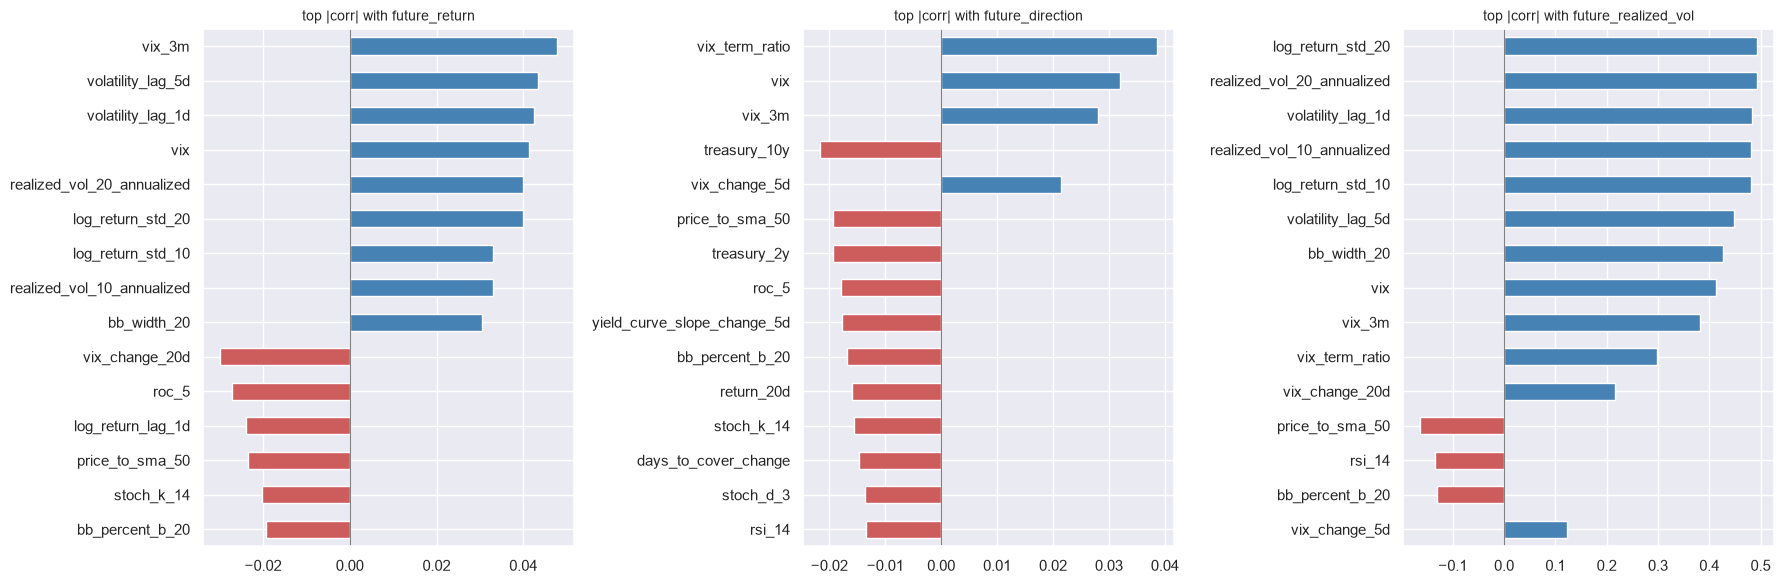

In [5]:
# Visual: top correlations per target as horizontal bars.
fig, axes = plt.subplots(1, len(targets), figsize=(6 * len(targets), 6))
axes = np.atleast_1d(axes)

for ax, target in zip(axes, targets):
    top = correlations[target].reindex(correlations[target].abs().sort_values(ascending=False).index).head(15)
    colors = ["steelblue" if value > 0 else "indianred" for value in top]
    top[::-1].plot.barh(ax=ax, color=colors[::-1])
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_title(f"top |corr| with {target}", fontsize=10)

plt.tight_layout()
plt.show()

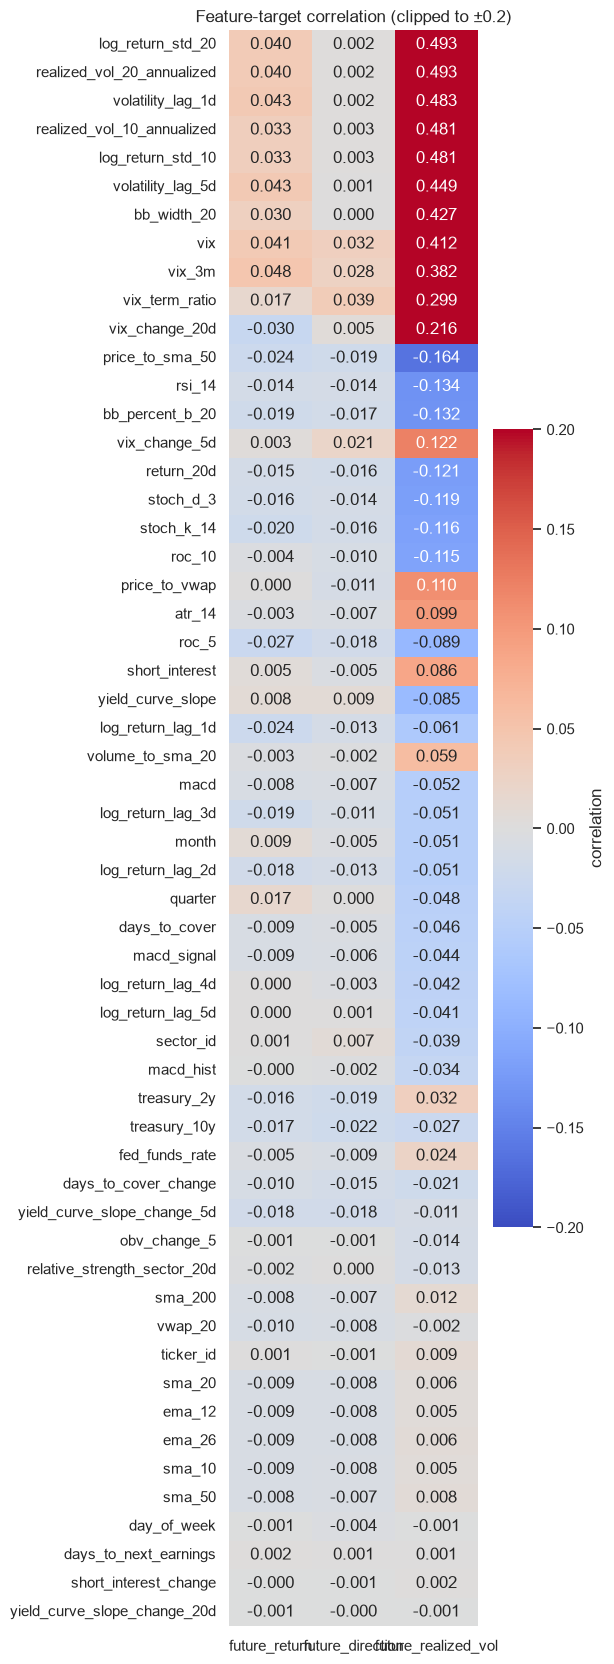

In [6]:
heatmap_data = pd.DataFrame(correlations)
heatmap_data = heatmap_data.reindex(
    heatmap_data.abs().max(axis=1).sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(6, max(8, len(heatmap_data) * 0.3)))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-0.2,
    vmax=0.2,
    cbar_kws={"shrink": 0.5, "label": "correlation"},
    ax=ax,
)
ax.set_title("Feature-target correlation (clipped to ±0.2)")
plt.tight_layout()
plt.show()

In [7]:
PRIMARY_TARGET = "future_return"
clean_target = data.dropna(subset=features + [PRIMARY_TARGET])

pearson = clean_target[features].corrwith(clean_target[PRIMARY_TARGET])
spearman = clean_target[features].corrwith(clean_target[PRIMARY_TARGET], method="spearman")

robustness = pd.DataFrame({"pearson": pearson, "spearman": spearman})
robustness["gap"] = (robustness["pearson"] - robustness["spearman"]).abs()
robustness = robustness.reindex(robustness["gap"].sort_values(ascending=False).index)

print("Largest Pearson/Spearman disagreement -- signal here is outlier-driven:")
display(robustness.head(15).round(4))

Largest Pearson/Spearman disagreement -- signal here is outlier-driven:


,pearson,spearman,gap
vix_term_ratio,-0.0034,0.0534,0.0568
vix_change_20d,-0.0636,-0.0144,0.0492
vix_change_5d,-0.0327,0.0040,0.0367
macd_signal,-0.0092,-0.0316,0.0223
vix,0.0385,0.0596,0.0211
roc_10,0.0035,-0.0175,0.0210
macd,-0.0082,-0.0290,0.0208
obv_change_5,-0.0001,-0.0178,0.0177
quarter,0.0290,0.0127,0.0163
volatility_lag_5d,0.0601,0.0438,0.0162


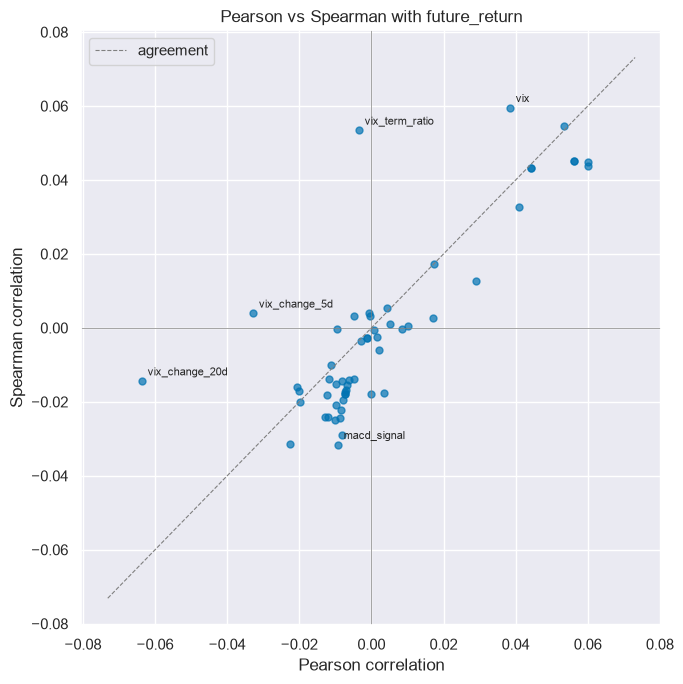

In [8]:
# Points far off the diagonal are features where the two measures disagree.
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(robustness["pearson"], robustness["spearman"], s=25, alpha=0.7)

limit = float(np.nanmax(np.abs(robustness[["pearson", "spearman"]].values))) * 1.15
ax.plot([-limit, limit], [-limit, limit], "grey", linestyle="--", linewidth=0.8, label="agreement")
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)

# Label the biggest disagreements.
for name, row in robustness.head(5).iterrows():
    ax.annotate(name, (row["pearson"], row["spearman"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Pearson correlation")
ax.set_ylabel("Spearman correlation")
ax.set_title(f"Pearson vs Spearman with {PRIMARY_TARGET}")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
yearly = clean_target.copy()
yearly["year"] = yearly["date"].dt.year

top_features_stability = pearson.abs().sort_values(ascending=False).head(10).index.tolist()
stability = pd.DataFrame({
    year: group[top_features_stability].corrwith(group[PRIMARY_TARGET])
    for year, group in yearly.groupby("year")
})

# A feature whose correlation changes sign across years is unstable.
stability["sign_flips"] = np.sign(stability).nunique(axis=1) > 1

print(f"{int(stability['sign_flips'].sum())} of {len(stability)} top features flip "
      f"correlation sign across years -- treat these as unreliable:")
display(stability.round(3))

7 of 10 top features flip correlation sign across years -- treat these as unreliable:


,2018,2019,2020,2021,2022,2023,2024,2025,2026,sign_flips
vix_change_20d,0.074,-0.034,-0.228,0.065,0.014,-0.035,0.067,0.073,-0.042,True
volatility_lag_5d,0.002,0.089,0.137,0.037,-0.012,0.099,0.019,0.074,-0.006,True
volatility_lag_1d,0.024,0.083,0.124,0.035,-0.002,0.097,0.037,0.079,-0.005,True
realized_vol_20_annualized,0.030,0.081,0.110,0.037,-0.000,0.094,0.041,0.079,-0.006,True
log_return_std_20,0.030,0.081,0.110,0.037,-0.000,0.094,0.041,0.079,-0.006,True
vix_3m,0.103,0.168,0.091,0.144,0.155,0.011,0.094,0.147,-0.010,True
log_return_std_10,0.024,0.057,0.070,0.033,0.003,0.080,0.064,0.075,0.004,False
realized_vol_10_annualized,0.024,0.057,0.070,0.033,0.003,0.080,0.064,0.075,0.004,False
bb_width_20,0.045,0.054,0.060,0.011,0.009,0.093,0.045,0.050,0.027,False
vix,0.111,0.161,0.012,0.164,0.150,0.000,0.108,0.125,-0.008,True


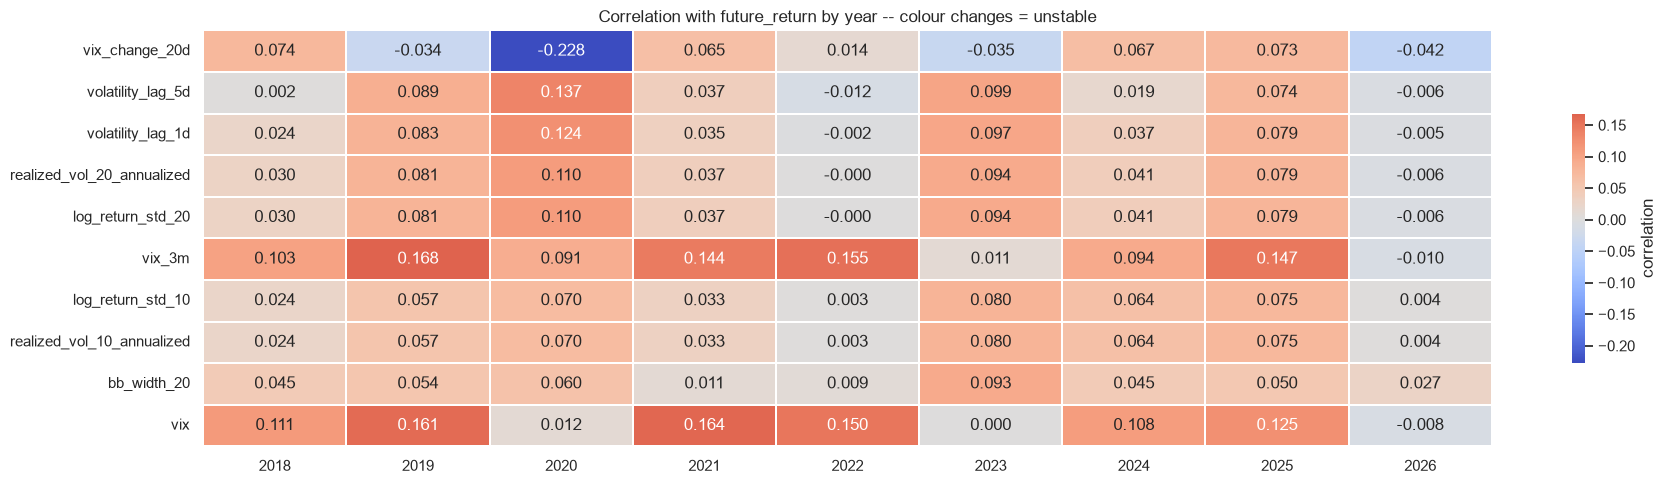

In [10]:
# Heatmap of yearly correlation. Rows that change colour across columns are the
# unstable features; rows holding one colour are the trustworthy ones.
yearly_only = stability.drop(columns="sign_flips")

fig, ax = plt.subplots(figsize=(1.6 * yearly_only.shape[1] + 4, 5))
sns.heatmap(yearly_only.astype(float), annot=True, fmt=".3f", cmap="coolwarm",
            center=0, linewidths=0.3, cbar_kws={"shrink": 0.6, "label": "correlation"}, ax=ax)
ax.set_title(f"Correlation with {PRIMARY_TARGET} by year -- colour changes = unstable")
plt.tight_layout()
plt.show()

In [11]:
LEAKAGE_THRESHOLD = 0.6

flagged = []
for target in targets:
    strong = correlations[target][correlations[target].abs() > LEAKAGE_THRESHOLD]
    for feature, value in strong.items():
        flagged.append({"feature": feature, "target": target, "corr": round(value, 4)})

if flagged:
    print(f"SUSPICIOUS -- |corr| > {LEAKAGE_THRESHOLD}, investigate for look-ahead bias:")
    display(pd.DataFrame(flagged))
else:
    print(f"No feature exceeds |corr| = {LEAKAGE_THRESHOLD} with any target. No leakage signature.")

No feature exceeds |corr| = 0.6 with any target. No leakage signature.


MemoryError: Unable to allocate 1.08 GiB for an array with shape (75, 1941090) and data type float64

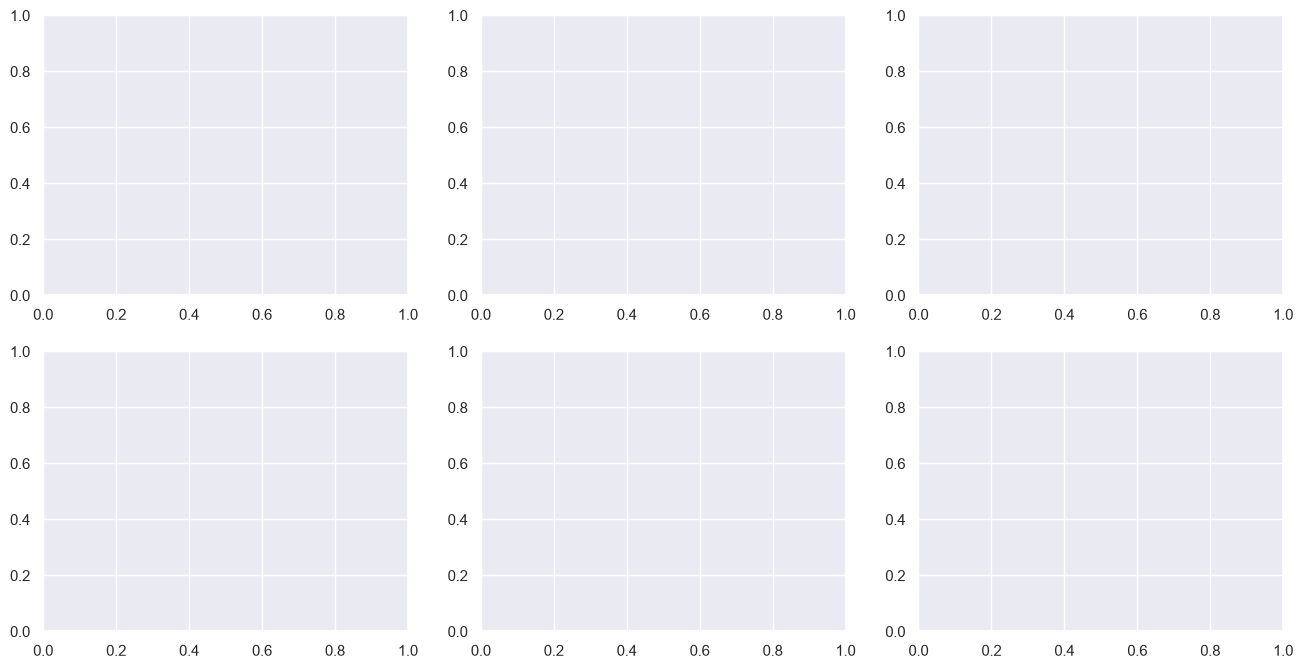

In [12]:
DECILE_TARGET = "future_return"
top_features = correlations[DECILE_TARGET].abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    clean = data.dropna(subset=[feature, DECILE_TARGET]).copy()
    clean["decile"] = pd.qcut(clean[feature], 10, labels=False, duplicates="drop")
    decile_means = clean.groupby("decile")[DECILE_TARGET].mean()
    colors = ["steelblue" if value >= 0 else "indianred" for value in decile_means]
    decile_means.plot.bar(ax=ax, color=colors)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(f"{feature}", fontsize=10)
    ax.set_xlabel("feature decile (low -> high)")
    ax.set_ylabel(f"mean {DECILE_TARGET}")

fig.suptitle(f"Decile analysis vs {DECILE_TARGET} -- look for a monotonic staircase", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

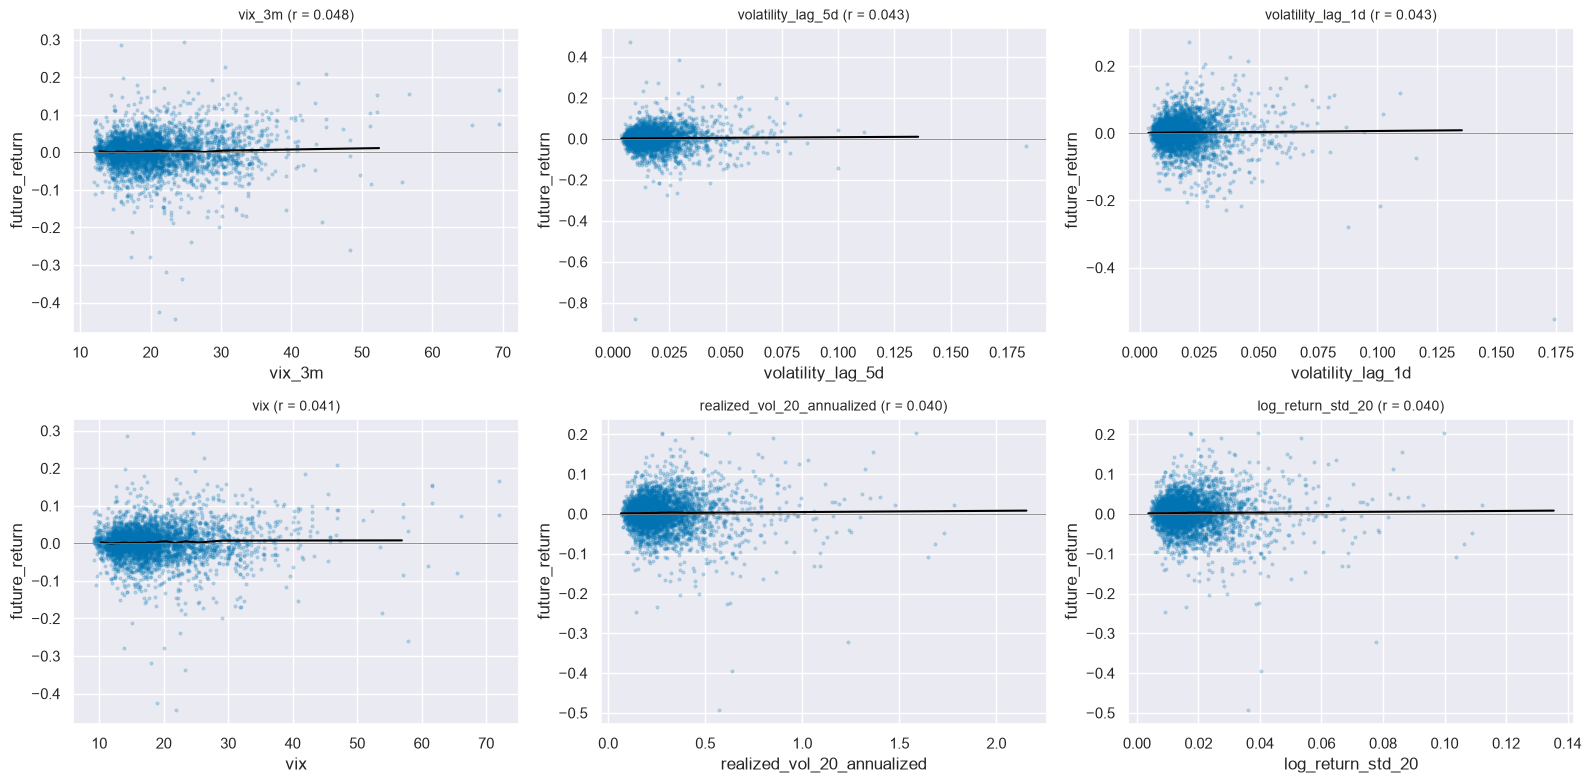

In [ ]:
SCATTER_SAMPLE = 4000

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    clean = data.dropna(subset=[feature, DECILE_TARGET])
    sample = clean.sample(min(SCATTER_SAMPLE, len(clean)), random_state=0)
    ax.scatter(sample[feature], sample[DECILE_TARGET], s=4, alpha=0.2)

    # binned mean line to cut through the noise
    bins = pd.qcut(clean[feature], 20, duplicates="drop")
    binned = clean.groupby(bins)[DECILE_TARGET].mean()
    centers = [interval.mid for interval in binned.index]
    ax.plot(centers, binned.values, color="black", linewidth=1.5)

    ax.axhline(0, color="grey", linewidth=0.6)
    ax.set_title(f"{feature} (r = {correlations[DECILE_TARGET][feature]:.3f})", fontsize=10)
    ax.set_xlabel(feature)
    ax.set_ylabel(DECILE_TARGET)

plt.tight_layout()
plt.show()

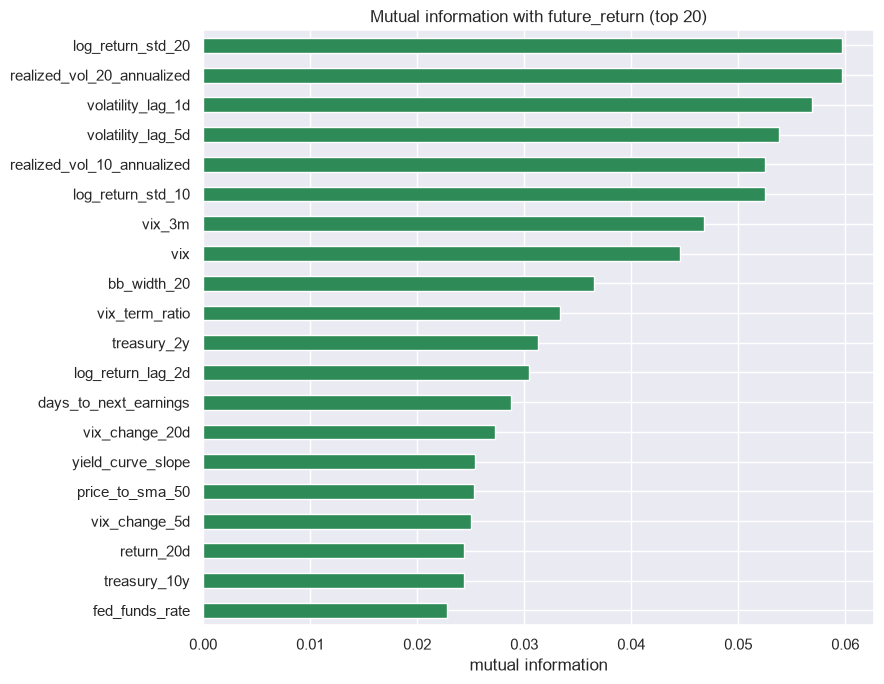

MI vs |correlation| -- features high in MI but low in corr are non-linear signal:


,mutual_info,abs_corr
log_return_std_20,0.0597,0.0400
realized_vol_20_annualized,0.0597,0.0400
volatility_lag_1d,0.0569,0.0425
volatility_lag_5d,0.0538,0.0433
realized_vol_10_annualized,0.0525,0.0330
log_return_std_10,0.0525,0.0330
vix_3m,0.0468,0.0478
vix,0.0445,0.0414
bb_width_20,0.0365,0.0304
vix_term_ratio,0.0333,0.0167


In [ ]:
MI_TARGET = "future_return"
clean = data.dropna(subset=features + [MI_TARGET])

# Sample for speed on large panels; MI estimation is expensive.
if len(clean) > 50_000:
    clean = clean.sample(50_000, random_state=0)

mi_scores = mutual_info_regression(clean[features], clean[MI_TARGET], random_state=0)
mi = pd.Series(mi_scores, index=features).sort_values(ascending=False)

comparison = pd.DataFrame({
    "mutual_info": mi,
    "abs_corr": correlations[MI_TARGET].abs(),
}).sort_values("mutual_info", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
mi.head(20)[::-1].plot.barh(ax=ax, color="seagreen")
ax.set_title(f"Mutual information with {MI_TARGET} (top 20)")
ax.set_xlabel("mutual information")
plt.tight_layout()
plt.show()

print("MI vs |correlation| -- features high in MI but low in corr are non-linear signal:")
display(comparison.head(15).round(4))

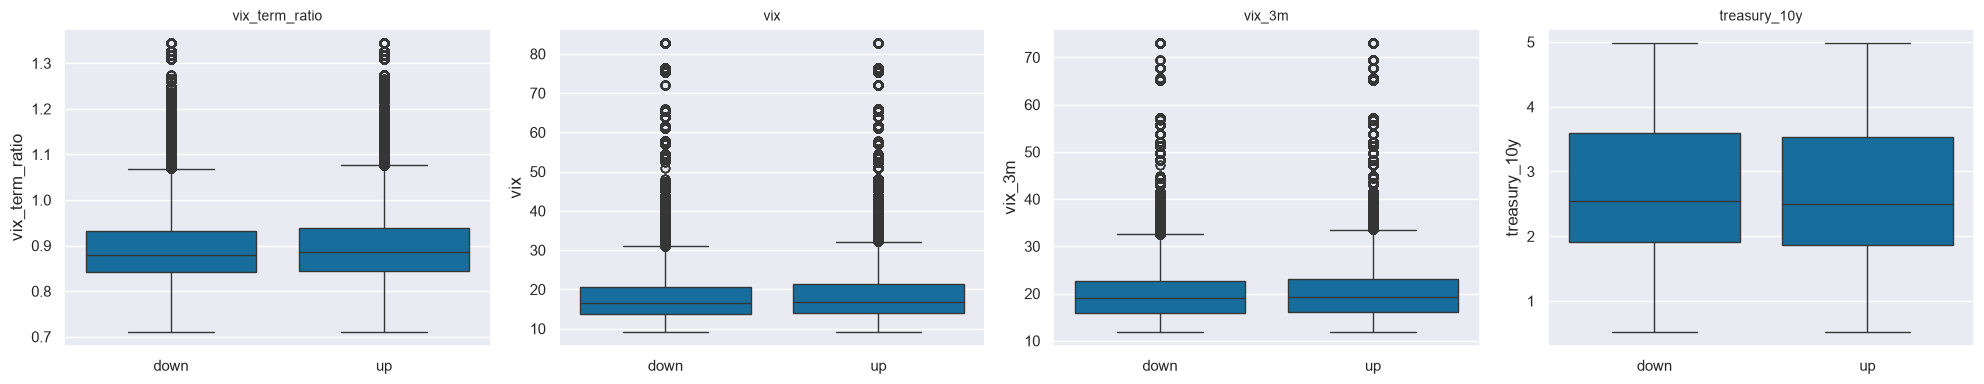

In [ ]:
if "future_direction" in targets:
    dir_features = correlations["future_direction"].abs().sort_values(ascending=False).head(4).index.tolist()
    clean = data.dropna(subset=dir_features + ["future_direction"]).copy()
    clean["direction"] = clean["future_direction"].map({0: "down", 1: "up"})

    fig, axes = plt.subplots(1, len(dir_features), figsize=(5 * len(dir_features), 4))
    axes = np.atleast_1d(axes)
    for ax, feature in zip(axes, dir_features):
        sns.boxplot(data=clean, x="direction", y=feature, order=["down", "up"], ax=ax)
        ax.set_title(feature, fontsize=10)
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()
else:
    print("future_direction not present.")

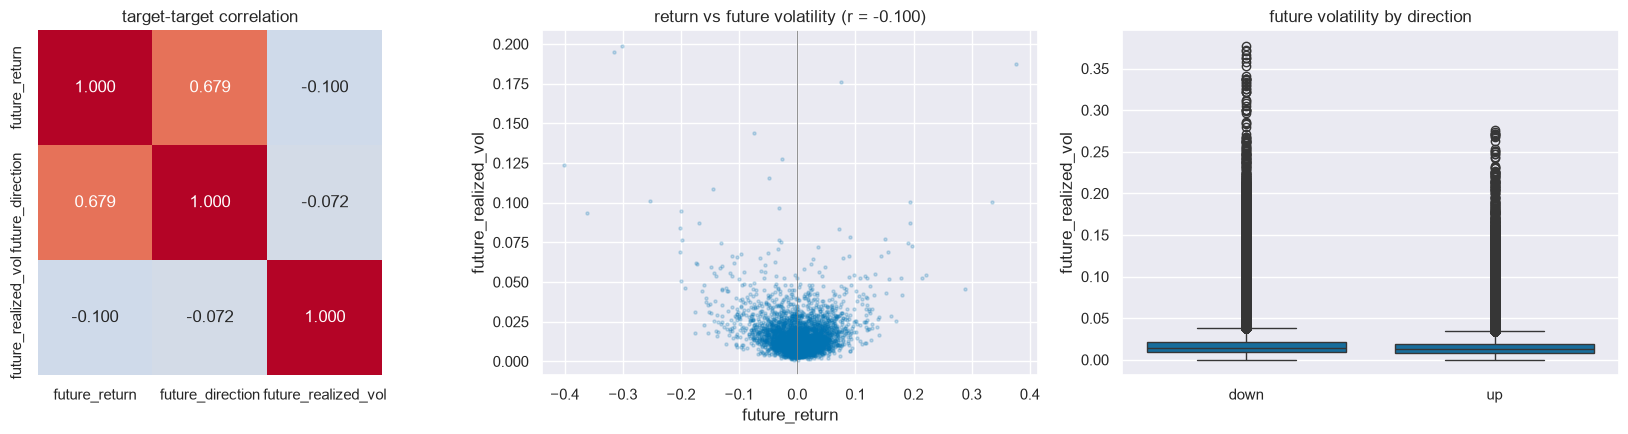

return vs realized_vol correlation : -0.0996
(near zero -> the return and volatility targets carry independent
 information, which the steered-drift design relies on)


In [ ]:
target_frame = data.dropna(subset=targets)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) target-target correlation heatmap
sns.heatmap(target_frame[targets].corr(), annot=True, fmt=".3f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, cbar=False, ax=axes[0])
axes[0].set_title("target-target correlation")

# (b) return vs realized vol -- the leverage effect
sample = target_frame.sample(min(4000, len(target_frame)), random_state=0)
axes[1].scatter(sample["future_return"], sample["future_realized_vol"], s=5, alpha=0.2)
axes[1].axvline(0, color="grey", linewidth=0.6)
leverage_corr = target_frame["future_return"].corr(target_frame["future_realized_vol"])
axes[1].set_title(f"return vs future volatility (r = {leverage_corr:.3f})")
axes[1].set_xlabel("future_return")
axes[1].set_ylabel("future_realized_vol")

# (c) volatility by direction class
if "future_direction" in target_frame.columns:
    plot_frame = target_frame.copy()
    plot_frame["direction"] = plot_frame["future_direction"].map({0: "down", 1: "up"})
    sns.boxplot(data=plot_frame, x="direction", y="future_realized_vol",
                order=["down", "up"], ax=axes[2])
    axes[2].set_title("future volatility by direction")
    axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

print(f"return vs realized_vol correlation : {leverage_corr:.4f}")
print("(near zero -> the return and volatility targets carry independent")
print(" information, which the steered-drift design relies on)")

In [ ]:
if not macro_present:
    print("No macro features in the dataset -- skipping.")
elif "future_realized_vol" not in data.columns:
    print("future_realized_vol not present -- skipping.")
else:
    proxy = "realized_vol_20_annualized"
    have_proxy = proxy in data.columns
    rows = []
    subset = data.dropna(subset=["future_realized_vol"] + macro_present + ([proxy] if have_proxy else []))
    for feature in macro_present:
        entry = {
            "macro_feature": feature,
            "corr_future_vol": subset[feature].corr(subset["future_realized_vol"]),
        }
        if have_proxy:
            entry["corr_rolling_vol"] = subset[feature].corr(subset[proxy])
        rows.append(entry)
    macro_signal = pd.DataFrame(rows).set_index("macro_feature")
    macro_signal["abs_target"] = macro_signal["corr_future_vol"].abs()
    macro_signal = macro_signal.sort_values("abs_target", ascending=False).drop(columns="abs_target")
    display(macro_signal.round(3))

    if have_proxy:
        strongest = macro_signal["corr_future_vol"].abs().max()
        redundant = macro_signal[macro_signal["corr_rolling_vol"].abs() > 0.8]
        print(f"\nStrongest macro-vs-future-vol correlation: {strongest:.3f}")
        if not redundant.empty:
            print(f"Macro features already >0.8 correlated with {proxy} "
                  f"(likely redundant): {list(redundant.index)}")
        else:
            print(f"No macro feature exceeds 0.8 correlation with {proxy} -- "
                  f"each may carry regime information the rolling feature does not.")

,corr_future_vol,corr_rolling_vol
macro_feature,,
vix,0.413,0.469
vix_3m,0.383,0.469
vix_term_ratio,0.300,0.251
vix_change_20d,0.216,-0.008
vix_change_5d,0.124,-0.056
yield_curve_slope,-0.087,-0.116
treasury_2y,0.033,0.040
treasury_10y,-0.027,-0.041
fed_funds_rate,0.025,0.029



Strongest macro-vs-future-vol correlation: 0.413
No macro feature exceeds 0.8 correlation with realized_vol_20_annualized -- each may carry regime information the rolling feature does not.


## The verdict

This is the earliest honest read on whether the project has legs.

- **Strongest correlations (and do they make economic sense?):**
- **Any leakage flagged?** (must be fixed before trusting anything downstream)
- **Any decile staircases?** (monotonic = real signal even when |r| is tiny)
- **Features high in MI but low in correlation:** (non-linear signal for the tree model)
- **Does `future_direction` separate at all?**

### Read it honestly

In equities, weak signal is the norm — |r| ≈ 0.03 with a clean monotonic decile pattern is genuinely usable. But if **every** feature is a flat cloud against **every** target, with no decile structure and negligible MI, that is a real finding: the current features do not predict the current target at the current horizon. Before building the model on top of that, it is worth trying a longer horizon, volatility as the target, or different features — the choices notebook 08 lays out. A clean negative here is information, not failure.